### DOES A VECTOR AUTOREGRESSION BEAT A UNIVARIATE AUTOREGRESSION AT FORECASTING INFLATION?
#### U.S. DATA (REPLICATION OF THE EURO-AREA ANALYSIS)

This notebook applies the identical methodology of the euro-area analysis to U.S. data,
as a replication on a second, independent economy. We compare a univariate **AR** model
(inflation from its own past) with a multivariate **VAR** model (inflation together with
unemployment and a short-term interest rate). The main question is:

> Does the VAR forecast U.S. inflation better than the AR?

The notebook is organised in three parts that follow the actual workflow:

- **Part I --- Univariate AR analysis:** build and evaluate the AR model on inflation alone.
- **Part II --- Multivariate VAR analysis:** build and evaluate the VAR with the two extra series.
- **Part III --- Comparison:** put both models (and the best AR we found) side by side.

In [ ]:
!pip install statsmodels --quiet

import requests
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.api import VAR
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats

import warnings
warnings.filterwarnings("ignore")

## Data

Three monthly U.S. series, all from FRED (Federal Reserve Bank of St.\ Louis), chosen to
mirror the euro-area variables:

| Variable | Meaning | FRED series |
|---|---|---|
| `inflation` | CPI-U all items, year-on-year rate of change (%) | `CPIAUCSL` (to YoY) |
| `unemployment` | Civilian unemployment rate (%) | `UNRATE` |
| `rate` | Effective federal funds rate (%) | `FEDFUNDS` |

We use the data up to the end of **2014** to set up the models and forecast from **2015**
onward (so the test period is never used when choosing the models).

In [ ]:
def load_fred(code):
    url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=" + code
    df = pd.read_csv(url)
    df.columns = ["date", "value"]
    s = pd.Series(pd.to_numeric(df["value"], errors="coerce").values,
                  index=pd.to_datetime(df["date"])).asfreq("MS")
    return s.interpolate(method="time", limit_area="inside")   # fill the rare missing month

cpi          = load_fred("CPIAUCSL")
inflation    = 100 * (cpi / cpi.shift(12) - 1)   # year-on-year CPI inflation
unemployment = load_fred("UNRATE")
rate         = load_fred("FEDFUNDS")

data = pd.DataFrame({"inflation": inflation, "unemployment": unemployment, "rate": rate})
data = data.dropna().loc["2000-01-01":]

spec_end  = "2014-12-01"      # end of the in-sample (training) period
oos_start = "2015-01-01"      # first month we forecast out-of-sample
train = data.loc[:spec_end]

print("Sample:", data.index.min().date(), "to", data.index.max().date(), "(%d months)" % len(data))
print("Training:", train.index.min().date(), "to", train.index.max().date(), "(%d months)" % len(train))
data.head()

Sample: 2000-01-01 to 2026-05-01 (317 months)
Training: 2000-01-01 to 2014-12-01 (180 months)


,inflation,unemployment,rate
date,,,
2000-01-01,2.792957,4.0,5.45
2000-02-01,3.217972,4.1,5.73
2000-03-01,3.762136,4.0,5.85
2000-04-01,3.013864,3.8,6.02
2000-05-01,3.132530,4.0,6.27


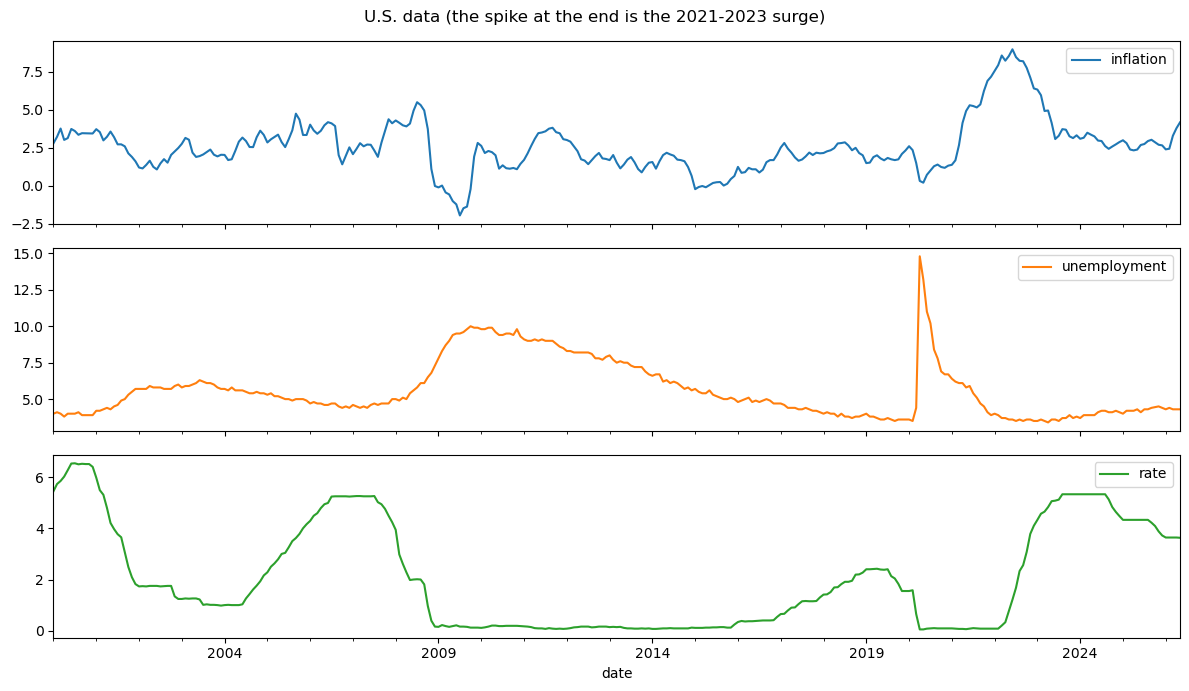

In [ ]:
data.plot(subplots=True, figsize=(12, 7), title="U.S. data (the spike at the end is the 2021-2023 surge)")
plt.tight_layout()
plt.show()

# Part I — Univariate AR analysis

Here we forecast inflation using **only its own past values**. This is the baseline that the
VAR will later have to beat.

## I.1 The inflation series

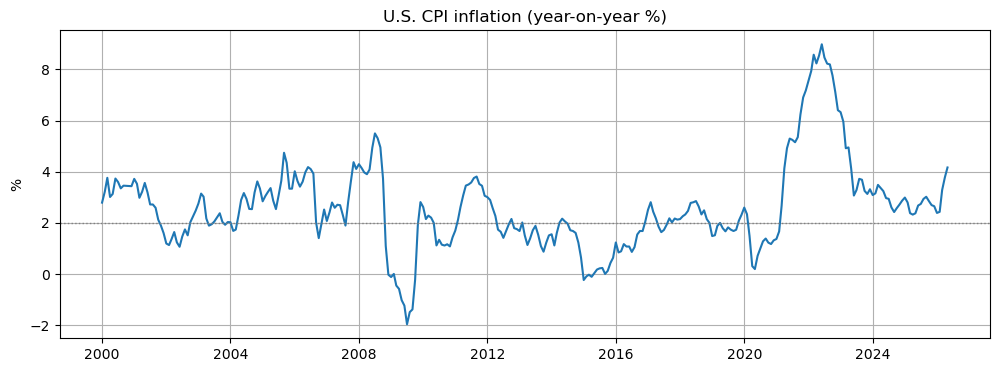

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(data.index, data["inflation"])
plt.axhline(2, color="grey", ls=":", lw=1)
plt.title("U.S. CPI inflation (year-on-year %)")
plt.ylabel("%"); plt.grid(True)
plt.show()

## I.2 Stationarity (ADF test)

An AR model needs a stationary series. We test inflation with the Augmented Dickey-Fuller
(ADF) test on the training sample. The null hypothesis is a unit root (non-stationary); a
small p-value (< 0.05) lets us reject it.

In [ ]:
def adf_test(series, name):
    series = series.dropna()
    pvalue = adfuller(series, regression="c", autolag="AIC")[1]
    decision = "reject unit root" if pvalue < 0.05 else "cannot reject unit root"
    print(f"{name:28s}  ADF p-value = {pvalue:.3f}   ->  {decision}")

adf_test(train["inflation"],        "inflation (level)")
adf_test(train["inflation"].diff(), "inflation (first difference)")

inflation (level)             ADF p-value = 0.260   ->  cannot reject unit root
inflation (first difference)  ADF p-value = 0.001   ->  reject unit root


The ADF test **cannot reject** a unit root for the inflation **level** (p around 0.26). This
is not proof of non-stationarity --- it only means we have no evidence against a unit root ---
but for modelling we treat the level as non-stationary. The **first difference** is clearly
stationary (p around 0.001), so we model inflation in first differences.

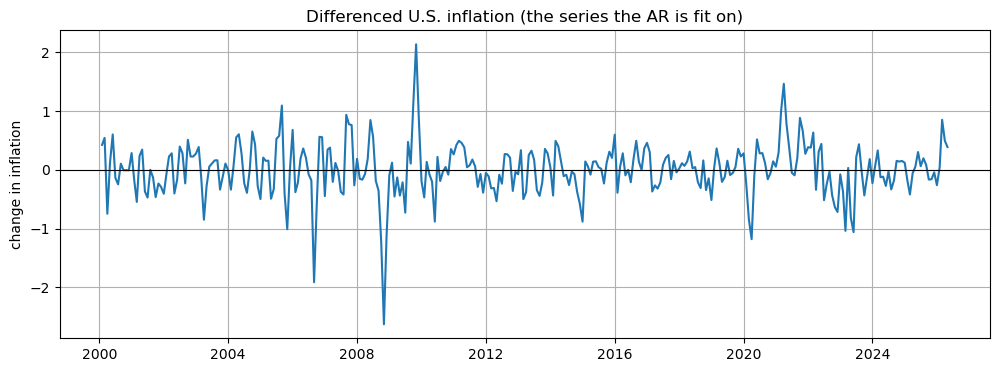

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(data.index, data["inflation"].diff())
plt.axhline(0, color="black", lw=0.8)
plt.title("Differenced U.S. inflation (the series the AR is fit on)")
plt.ylabel("change in inflation"); plt.grid(True)
plt.show()

## I.3 Choosing the lag length

We pick the lag with information criteria on the differenced training data, using `hold_back`
so every lag is estimated on the same sample (otherwise the criteria are not comparable
across lags).

In [ ]:
def ar_lag_table(series, max_lag=24):
    rows = []
    for p in range(1, max_lag + 1):
        m = AutoReg(series, lags=p, trend="c", old_names=False, hold_back=max_lag).fit()
        rows.append({"lag": p, "AIC": m.aic, "BIC": m.bic, "HQIC": m.hqic})
    return pd.DataFrame(rows).set_index("lag")

def with_stars(table):
    # mark the minimum of each criterion with a *, like statsmodels' VAR order summary
    mins = {c: table[c].idxmin() for c in table.columns}
    out = pd.DataFrame(index=table.index)
    for c in table.columns:
        out[c] = [f"{v:.2f}" + ("*" if lag == mins[c] else "") for lag, v in table[c].items()]
    return out

ar_table = ar_lag_table(train["inflation"].diff().dropna())
print("AR lag-order selection (* = minimum of each criterion)")
display(with_stars(ar_table))

ar_aic, ar_bic, ar_hqic = int(ar_table.AIC.idxmin()), int(ar_table.BIC.idxmin()), int(ar_table.HQIC.idxmin())
print("AIC ->", ar_aic, "  BIC ->", ar_bic, "  HQIC ->", ar_hqic)
ar_p = ar_aic
print("Chosen AR lag (AIC):", ar_p)

AR lag-order selection (* = minimum of each criterion)


,AIC,BIC,HQIC
lag,,,
1,208.46,217.59,212.16
2,199.41,211.58,204.35
3,201.38,216.60,207.56
4,202.80,221.06,210.22
5,200.68,221.99,209.34
6,201.90,226.25,211.79
7,203.46,230.85,214.59
8,203.69,234.13,216.06
9,203.07,236.55,216.67


AIC -> 24   BIC -> 12   HQIC -> 15
Chosen AR lag (AIC): 24


AIC selects the **largest lag considered (24)** --- a boundary choice that reflects the strong
persistence and seasonality of U.S. inflation (and AIC's tendency to over-fit here); BIC picks
the more parsimonious **12** (the yearly seasonal lag) and HQIC picks 15. Following the same
rule as the euro-area analysis (AIC), we use **AR(24)** as the best univariate model, keeping
in mind that it is a richly parameterised, boundary choice.

## I.4 Fit and residual diagnostics

A well-specified AR should leave **white-noise residuals** (no leftover autocorrelation). We
check this with the residual ACF and the Ljung-Box test.

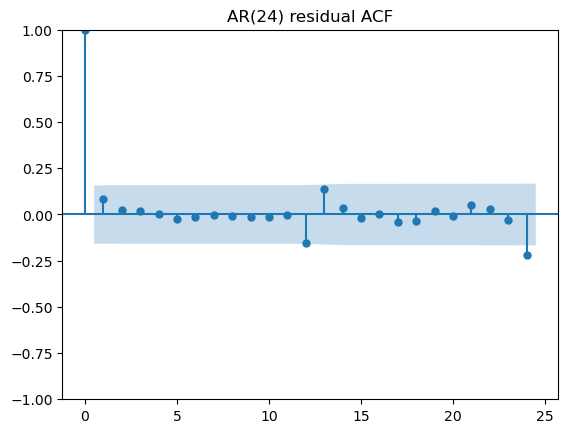

      lb_stat  lb_pvalue
30  21.221023   0.001674
36  24.681348   0.016407


In [ ]:
ar_model = AutoReg(train["inflation"].diff().dropna(), lags=ar_p, trend="c", old_names=False).fit()

plot_acf(ar_model.resid, lags=24)
plt.title(f"AR({ar_p}) residual ACF")
plt.show()

# Ljung-Box on the residuals, with model_df = ar_p so the chi-square df accounts for the
# fitted lags; we test at lags beyond ar_p, where the test is meaningful
print(acorr_ljungbox(ar_model.resid, lags=[ar_p + 6, ar_p + 12], model_df=ar_p, return_df=True))

Even at 24 lags some structure remains: the Ljung-Box test (adjusted for the fitted lags via
`model_df`) **rejects** at lags 30 and 36 (p around 0.002 and 0.016). So the AR(24) residuals
are not fully white --- U.S. inflation has dynamics that even a high-order AR does not
completely capture, a first sign that this series is harder to model than the euro-area one.

## I.5 Forecasting: AR vs no-change

We forecast inflation out-of-sample with an **expanding window** (re-estimated at every step,
no look-ahead) and compare the AR against the naive **no-change (random walk)** benchmark.
Because we model differences, we rebuild the inflation level by adding the forecast change(s)
to the last observed value.

In [ ]:
# --- forecasting building blocks (used in all three parts) ---
def forecast_ar(history, p, h):
    d = history["inflation"].diff().dropna()
    ch = AutoReg(d, lags=p, trend="c", old_names=False).fit().forecast(steps=h).to_numpy()
    return history["inflation"].iloc[-1] + np.cumsum(ch)[-1]

def forecast_rw(history, h):
    return history["inflation"].iloc[-1]

def backtest(h, models):
    # models: dict name -> function(history, h)
    rows = []
    for date in data.index[data.index >= pd.Timestamp(oos_start)]:
        history = data.loc[:date - pd.DateOffset(months=h)]
        if len(history) < 60:
            continue
        row = {"date": date, "actual": data["inflation"].loc[date]}
        for name, fn in models.items():
            row[name] = fn(history, h)
        rows.append(row)
    return pd.DataFrame(rows).set_index("date")

def accuracy(fc, model):
    e = fc["actual"] - fc[model]
    return np.sqrt(np.mean(e**2)), np.mean(np.abs(e))

def diebold_mariano(error1, error2, nlags=6):
    # equal-accuracy test with a Newey-West (HAC) variance; small p = significant difference
    d = error1**2 - error2**2
    n = len(d); dc = d - d.mean()
    var = np.sum(dc**2) / n
    for k in range(1, nlags + 1):
        var += 2 * (1 - k / (nlags + 1)) * np.sum(dc[k:] * dc[:-k]) / n
    stat = d.mean() / np.sqrt(var / n)
    return 2 * (1 - stats.norm.cdf(abs(stat)))

ar_fc = backtest(1, {"AR24": lambda H, h: forecast_ar(H, ar_p, h),
                     "RW":   forecast_rw})
print("One-step-ahead accuracy (2015 onward)")
for m in ["AR24", "RW"]:
    rmse, mae = accuracy(ar_fc, m)
    print(f"  {m:5s}: RMSE = {rmse:.3f}   MAE = {mae:.3f}")
print("\nDiebold-Mariano, AR(24) vs RW: p-value =",
      round(diebold_mariano((ar_fc.actual-ar_fc.AR24).values, (ar_fc.actual-ar_fc.RW).values), 3))

One-step-ahead accuracy (2015 onward)
  AR24 : RMSE = 0.302   MAE = 0.236
  RW   : RMSE = 0.385   MAE = 0.281

Diebold-Mariano, AR(24) vs RW: p-value = 0.071


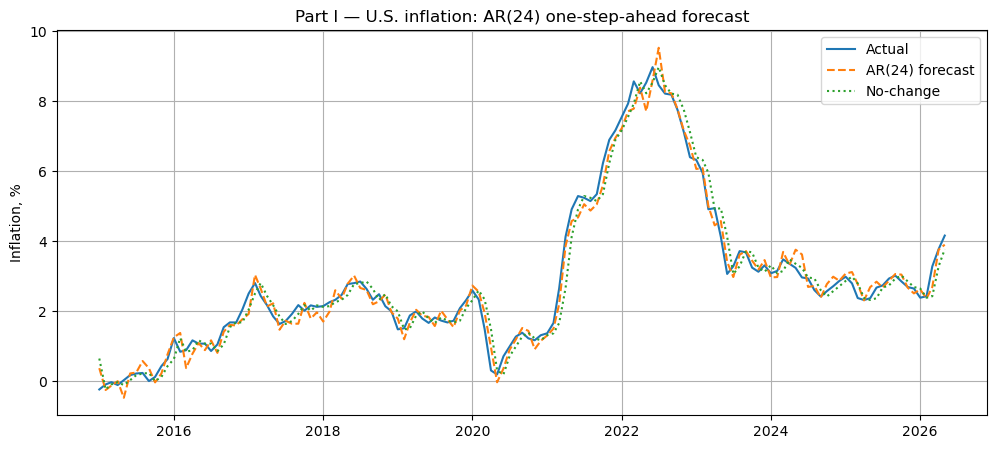

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(ar_fc.index, ar_fc["actual"], label="Actual", linewidth=1.5)
plt.plot(ar_fc.index, ar_fc["AR24"], "--", label=f"AR({ar_p}) forecast")
plt.plot(ar_fc.index, ar_fc["RW"], ":", label="No-change")
plt.title(f"Part I — U.S. inflation: AR({ar_p}) one-step-ahead forecast")
plt.ylabel("Inflation, %"); plt.legend(); plt.grid(True)
plt.show()

In [ ]:
print("AR vs RW, RMSE by horizon")
print("h    AR(24)  RW")
for h in [1, 3, 6, 12]:
    fc = backtest(h, {"AR24": lambda H, hh: forecast_ar(H, ar_p, hh), "RW": forecast_rw})
    print(f"{h:<3}  {accuracy(fc,'AR24')[0]:.3f}   {accuracy(fc,'RW')[0]:.3f}")

AR vs RW, RMSE by horizon
h    AR(24)  RW


1    0.302   0.385


3    0.800   0.881


6    1.392   1.375


12   2.502   2.270


## I.6 Part I conclusion

The **AR(24)** is the best univariate model by AIC. It beats the no-change benchmark on RMSE
at short and medium horizons, though the gap is only **marginally significant**
(Diebold-Mariano p around 0.07), and its residuals are not perfectly white --- so it is an
adequate rather than a fully satisfactory fit. This is the baseline the VAR has to beat.

# Part II — Multivariate VAR analysis

Now we add **unemployment** and the **interest rate** and build a three-variable VAR, to see
whether this extra information improves the inflation forecast.

## II.1 Stationarity of all three series

A VAR needs every component stationary. We run the ADF test on each series (training sample).

In [ ]:
print("LEVELS")
for col in data.columns:
    adf_test(train[col], col)
print("\nFIRST DIFFERENCES")
for col in data.columns:
    adf_test(train[col].diff(), col + " (diff)")

LEVELS
inflation                     ADF p-value = 0.260   ->  cannot reject unit root
unemployment                  ADF p-value = 0.229   ->  cannot reject unit root
rate                          ADF p-value = 0.017   ->  reject unit root

FIRST DIFFERENCES
inflation (diff)              ADF p-value = 0.001   ->  reject unit root
unemployment (diff)           ADF p-value = 0.086   ->  cannot reject unit root
rate (diff)                   ADF p-value = 0.011   ->  reject unit root


Inflation and unemployment are non-stationary in levels; the interest rate borderline-rejects
a unit root, but we difference it too for a consistent specification. In first differences the
series are stationary --- with one caveat: **U.S. unemployment is borderline** (its differenced
ADF p is only around 0.09), hinting at near-$I(2)$ behaviour driven by the sharp 2020 spike. We
nonetheless model the VAR in **first differences** --- the same transformation the AR uses ---
and flag the unemployment caveat.

In [ ]:
data_diff = data.diff().dropna()

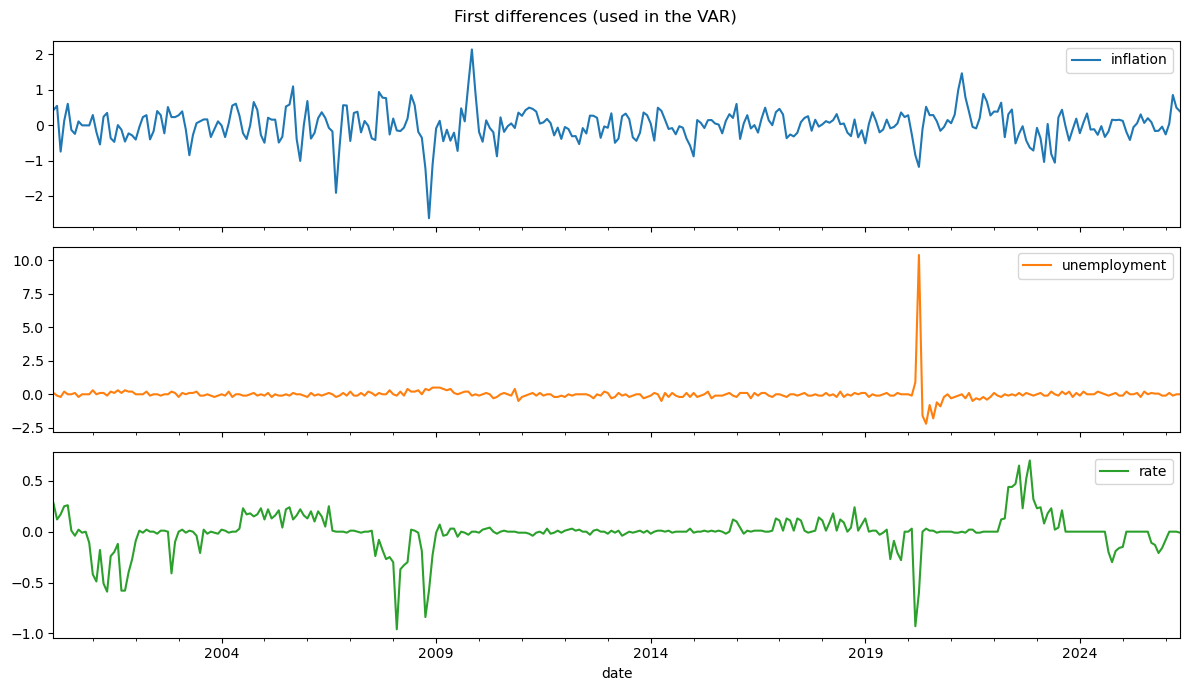

In [ ]:
data_diff.plot(subplots=True, figsize=(12, 7), title="First differences (used in the VAR)")
plt.tight_layout()
plt.show()

## II.2 Cointegration check (Johansen test)

If the non-stationary series share a long-run relationship (cointegration), a VAR in
differences would be wrong and we would need a VECM instead. We test this with the Johansen
trace test (null hypothesis: cointegration rank at most r).

In [ ]:
johansen = coint_johansen(train.values, det_order=0, k_ar_diff=2)
print("Johansen trace test")
print("rank r | trace stat | 5% critical | reject H0?")
rank = 0
for r in range(len(johansen.lr1)):
    stat, crit = johansen.lr1[r], johansen.cvt[r, 1]
    reject = stat > crit
    rank += int(reject)
    print(f"   {r}   |   {stat:7.2f}  |   {crit:7.2f}   |   {reject}")
print("\nCointegration rank:", rank)

Johansen trace test
rank r | trace stat | 5% critical | reject H0?
   0   |     25.70  |     29.80   |   False
   1   |      7.92  |     15.49   |   False
   2   |      1.23  |      3.84   |   False

Cointegration rank: 0


The trace statistic at rank 0 (25.70) is **below** the 5% critical value (29.80), and higher
ranks are not rejected either, so there is **no evidence of cointegration**. Differencing
therefore discards no long-run information and a **VAR in first differences** is the correct
specification (no VECM needed). Unlike the euro-area sample, where the test was borderline, the
U.S. result is clear-cut.

## II.3 Choosing the lag length

A VAR with K=3 variables and p lags has 9p slope coefficients, so the lag choice trades off
capturing structure against over-fitting. We compute the standard information criteria.

In [ ]:
selection = VAR(data_diff.loc[:spec_end]).select_order(maxlags=24)
print(selection.summary())                       # full table, * marks each criterion's minimum
print("\nAIC ->", selection.aic, "  FPE ->", selection.fpe,
      "  BIC ->", selection.bic, "  HQIC ->", selection.hqic)

# the criteria disagree strongly, so we carry two representative cases forward
var_p_small = selection.hqic    # parsimonious (HQIC = 2, BIC = 1)
var_p_large = selection.aic     # rich (AIC and FPE both select 12)
var_p = var_p_small             # alias used by the shared backtest helpers
print("Two cases carried forward: VAR(%d) and VAR(%d)" % (var_p_small, var_p_large))

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -8.639      -8.580   0.0001771      -8.615
1       -9.437     -9.201*   7.972e-05      -9.341
2       -9.537      -9.124   7.217e-05     -9.369*
3       -9.556      -8.967   7.078e-05      -9.317
4       -9.483      -8.717   7.624e-05      -9.172
5       -9.571      -8.629   6.986e-05      -9.188
6       -9.530      -8.411   7.293e-05      -9.075
7       -9.481      -8.185   7.676e-05      -8.954
8       -9.501      -8.028   7.545e-05      -8.902
9       -9.518      -7.869   7.439e-05      -8.848
10      -9.484      -7.658   7.735e-05      -8.742
11      -9.456      -7.453   7.993e-05      -8.643
12     -9.814*      -7.634  5.627e-05*      -8.928
13      -9.803      -7.446   5.733e-05      -8.845
14      -9.722      -7.189   6.268e-05      -8.694
15      -9.795      -7.086   5.887e-05      -8.695
16      -9.717      -6.831   6.

The criteria disagree sharply: **BIC selects 1, HQIC selects 2, and AIC and FPE both select
12** lags (the yearly seasonal structure). Rather than commit to a single order, we treat the
two ends of this range as **equally interesting cases** and carry both forward: a
**parsimonious VAR(2)** (the HQIC/BIC region, 21 coefficients) and a **rich VAR(12)** (the
AIC/FPE choice, over 100 coefficients). The small model risks leaving structure unmodelled;
the large model risks over-fitting. We examine the diagnostics and the forecasts of both.

## II.4 Fit and diagnostics

For **each** candidate --- VAR(2) and VAR(12) --- we check **stability**, **residual
whiteness** (multivariate Ljung-Box / Hosking), and **Granger causality** (do the extra
series help predict inflation?).

In [ ]:
var_models = {p: VAR(data_diff.loc[:spec_end]).fit(p) for p in [var_p_small, var_p_large]}
print("model    stable   whiteness p   Granger p")
for p, m in var_models.items():
    white = m.test_whiteness(nlags=24, adjusted=True).pvalue      # nlags > p for both models
    gc = m.test_causality("inflation", ["unemployment", "rate"], kind="f").pvalue
    print(f"VAR({p:2d})   {str(m.is_stable()):6s}   {white:11.3f}   {gc:.3f}")

model    stable   whiteness p   Granger p
VAR( 2)   True           0.000   0.051
VAR(12)   True           0.001   0.013


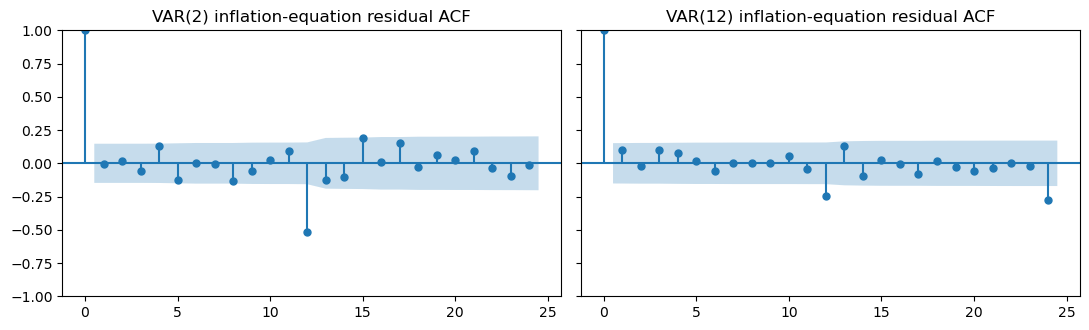

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), sharey=True)
for ax, p in zip(axes, [var_p_small, var_p_large]):
    plot_acf(var_models[p].resid["inflation"], lags=24, ax=ax)
    ax.set_title(f"VAR({p}) inflation-equation residual ACF")
plt.tight_layout(); plt.show()

Both VARs are stable but **neither has white residuals**: the Hosking test rejects for VAR(2)
(p around 0.00) and, only slightly less strongly, for VAR(12) (p around 0.001). The residual
ACFs above show the difference --- VAR(2) still spikes near lag 12, whereas VAR(12) reduces
the within-year autocorrelation, but only by spending over 100 coefficients. Granger causality
from unemployment and the rate to inflation is **borderline** and, notably, stronger in the
richer model (p around 0.05 for VAR(2), 0.01 for VAR(12)) --- a hint of genuine cross-series
content, unlike the clearly insignificant euro-area result. Whether either specification turns
that hint into better *forecasts* is what the out-of-sample test decides next.

## II.5 Forecasting: the two VARs vs the best AR and no-change

We compare both VARs out-of-sample against the **best univariate AR(24)** from Part I and the
**no-change** benchmark. Beating the best AR is the fair test of whether the VAR is useful.

*Note on the DM test:* the VAR's expanding-window errors are heavy-tailed (a few explosive
values in the COVID window), which inflates the Diebold-Mariano variance. So even where the
VAR's RMSE is clearly larger, the DM p-value can stay above 5% --- the insignificance reflects
the VAR's instability, not a close contest.

In [ ]:
def forecast_var(history, p, h):
    d = history.diff().dropna()
    fc = VAR(d).fit(p).forecast(d.values[-p:], steps=h)
    return history["inflation"].iloc[-1] + np.cumsum(fc[:, 0])[-1]

var_fc = backtest(1, {"VAR2":   lambda H, h: forecast_var(H, var_p_small, h),
                      "VAR12":  lambda H, h: forecast_var(H, var_p_large, h),
                      "ARbest": lambda H, h: forecast_ar(H, ar_p, h),          # best univariate (Part I)
                      "RW":     forecast_rw})
print("One-step-ahead accuracy (2015 onward)")
for m in ["VAR2", "VAR12", "ARbest", "RW"]:
    r, a = accuracy(var_fc, m)
    print(f"  {m:7s}: RMSE = {r:.3f}   MAE = {a:.3f}")

e = {m: (var_fc["actual"] - var_fc[m]).values for m in ["VAR2", "VAR12", "ARbest", "RW"]}
print("\nDiebold-Mariano p-values:")
print(f"  VAR(2)  vs AR({ar_p}) :", round(diebold_mariano(e['VAR2'],  e['ARbest']), 3))
print(f"  VAR(12) vs AR({ar_p}) :", round(diebold_mariano(e['VAR12'], e['ARbest']), 3))
print(f"  VAR(2)  vs RW     :", round(diebold_mariano(e['VAR2'],  e['RW']), 3))
print(f"  VAR(12) vs RW     :", round(diebold_mariano(e['VAR12'], e['RW']), 3))
print(f"  AR({ar_p})    vs RW  :", round(diebold_mariano(e['ARbest'], e['RW']), 3))

One-step-ahead accuracy (2015 onward)
  VAR2   : RMSE = 0.402   MAE = 0.278
  VAR12  : RMSE = 0.668   MAE = 0.371
  ARbest : RMSE = 0.302   MAE = 0.236
  RW     : RMSE = 0.385   MAE = 0.281

Diebold-Mariano p-values:
  VAR(2)  vs AR(24) : 0.113
  VAR(12) vs AR(24) : 0.133
  VAR(2)  vs RW     : 0.705
  VAR(12) vs RW     : 0.193
  AR(24)    vs RW  : 0.071


In [ ]:
print("RMSE by horizon")
print(f"h    VAR(2)  VAR(12)  AR({ar_p})  RW")
for h in [1, 3, 6, 12]:
    fc = backtest(h, {"VAR2":  lambda H, hh: forecast_var(H, var_p_small, hh),
                      "VAR12": lambda H, hh: forecast_var(H, var_p_large, hh),
                      "ARb":   lambda H, hh: forecast_ar(H, ar_p, hh),
                      "RW":    forecast_rw})
    print(f"{h:<3}  {accuracy(fc,'VAR2')[0]:.3f}   {accuracy(fc,'VAR12')[0]:7.3f}  "
          f"{accuracy(fc,'ARb')[0]:6.3f}  {accuracy(fc,'RW')[0]:.3f}")

RMSE by horizon
h    VAR(2)  VAR(12)  AR(24)  RW


1    0.402     0.668   0.302  0.385


3    1.215     1.693   0.800  0.881


6    3.093     5.313   1.392  1.375


12   14.467    26.854   2.502  2.270


## II.7 Part II conclusion

Neither VAR helps. VAR(2) is worse than the best univariate AR(24) at every horizon (and worse
than no-change at $h=1$) and becomes **unstable at long horizons**, its forecasts exploding by
$h=12$ (the differenced VAR extrapolating the 2020 unemployment spike). The rich **VAR(12)**
forecasts even worse and explodes more violently still. The Diebold-Mariano tests do not reach
5% significance --- not because the contest is close (the RMSE gaps are large) but because the
VAR's heavy-tailed errors inflate the test's variance. So despite the borderline (and, for
VAR(12), significant) Granger signal, the extra variables do not improve U.S. inflation
forecasts at either lag length; here they actively hurt.

# Part III --- AR vs VAR: putting it together

Finally we compare all the models on the same out-of-sample test: the **VAR(2)**, the
AIC/FPE-preferred **VAR(12)**, the best univariate **AR(24)** from Part I, and the
**no-change** benchmark.

In [ ]:
print("RMSE by forecast horizon (lower is better)")
print("h    VAR(2)  VAR(12)  AR(24)  RW")
for h in [1, 3, 6, 12]:
    fc = backtest(h, {"VAR":   lambda H, hh: forecast_var(H, var_p, hh),
                      "VAR12": lambda H, hh: forecast_var(H, 12, hh),
                      "AR24":  lambda H, hh: forecast_ar(H, ar_p, hh),
                      "RW":    forecast_rw})
    print(f"{h:<3}  {accuracy(fc,'VAR')[0]:.3f}   {accuracy(fc,'VAR12')[0]:7.3f}  "
          f"{accuracy(fc,'AR24')[0]:.3f}   {accuracy(fc,'RW')[0]:.3f}")

allfc = backtest(1, {"VAR":   lambda H, h: forecast_var(H, var_p, h),
                     "VAR12": lambda H, h: forecast_var(H, 12, h),
                     "AR24":  lambda H, h: forecast_ar(H, ar_p, h),
                     "RW":    forecast_rw})
print("\nDiebold-Mariano (one-step):")
print("  VAR(2)  vs AR(24):", round(diebold_mariano((allfc.actual-allfc.VAR).values,   (allfc.actual-allfc.AR24).values), 3))
print("  VAR(12) vs AR(24):", round(diebold_mariano((allfc.actual-allfc.VAR12).values, (allfc.actual-allfc.AR24).values), 3))
print("  VAR(2)  vs RW    :", round(diebold_mariano((allfc.actual-allfc.VAR).values,   (allfc.actual-allfc.RW).values), 3))
print("  AR(24)  vs RW    :", round(diebold_mariano((allfc.actual-allfc.AR24).values,  (allfc.actual-allfc.RW).values), 3))

RMSE by forecast horizon (lower is better)
h    VAR(2)  VAR(12)  AR(24)  RW


1    0.402     0.668  0.302   0.385


3    1.215     1.693  0.800   0.881


6    3.093     5.313  1.392   1.375


12   14.467    26.854  2.502   2.270



Diebold-Mariano (one-step):
  VAR(2)  vs AR(24): 0.113
  VAR(12) vs AR(24): 0.133
  VAR(2)  vs RW    : 0.705
  AR(24)  vs RW    : 0.071


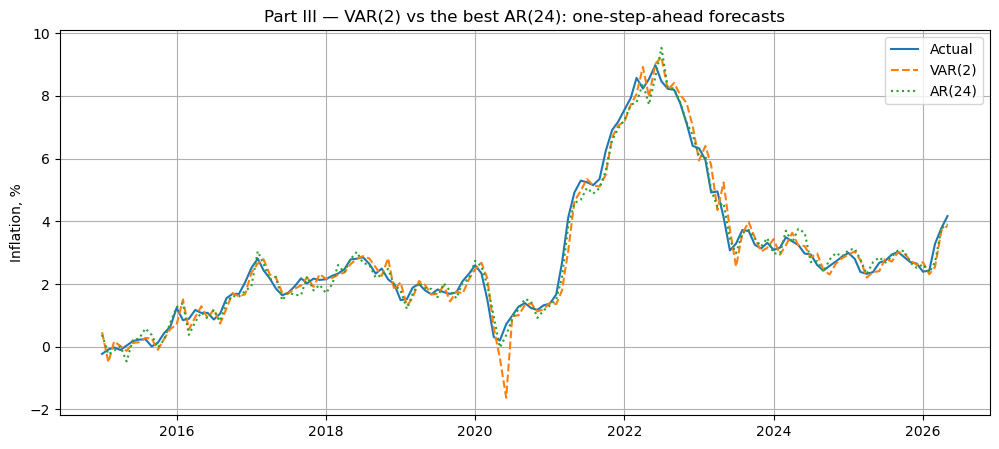

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(allfc.index, allfc["actual"], label="Actual", linewidth=1.5)
plt.plot(allfc.index, allfc["VAR"],  "--", label="VAR(2)")
plt.plot(allfc.index, allfc["AR24"], ":",  label="AR(24)")
plt.title("Part III — VAR(2) vs the best AR(24): one-step-ahead forecasts")
plt.ylabel("Inflation, %"); plt.legend(); plt.grid(True)
plt.show()

## Overall conclusion

For U.S. inflation, the **VAR does not beat the AR** --- if anything it does worse.

- **Granger causality is borderline** (p around 0.05): unemployment and the interest rate come
  close to carrying incremental information for inflation, more so than in the euro area. But
  this in-sample hint does not survive out of sample.
- The **VAR(12)** that AIC and FPE prefer does not rescue the multivariate model: with its
  $9\times 12$ coefficients it forecasts *worse* than the VAR(2) at every horizon and explodes
  even more violently at $h=12$ (RMSE near 27) --- a textbook illustration of the parameter cost.
- The **best univariate AR(24)** is the most accurate model at $h=1,3$ and competitive
  elsewhere; the VAR does not beat it.
- In the **one-step** comparison, only the univariate models beat no-change, and only
  marginally (p around 0.07); the VAR does not (p around 0.71).

So, as in the euro area, adding more variables does not improve the U.S. inflation forecast;
here the multivariate model is not merely tied with the AR but is worse and less stable. This
reinforces the euro-area finding and the literature's message that simple univariate models are
hard to beat.

**Caveats:** the data are revised (not real-time); U.S. unemployment is borderline $I(2)$; the
VAR(2) residuals are far from white and the model is unstable at long horizons; and the
COVID-19 shock and the 2021--2023 surge dominate the errors.